Answer the following questions in the appropriate locations in the "Assignment 1 test" SunLearn quiz, doing calculations in this notebook where necessary/desired.  __Give answers rounded to 4 decimal places - answers must be exactly correct to receive marks.__

---------

*Beantwoord die volgende vrae in die toepaslike plekke in die "Taak 1 toets" SunLearn quiz, en doen u berekeninge in hierdie notaboek waar nodig/gewens. __Gee antwoorde gerond tot 4 desimale plekke - antwoorde moet presies korrek wees om punte te ontvang.__*

---------

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import numpy as np
from matplotlib import pylab as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Import different modules for using with the notebook
from IPython.display import display
from IPython.display import Image
from IPython.display import HTML

**Question 1 (6 marks).** Consider the 4x2 matrix $M$ below. // __*Vraag 1 (6 punte).*__ *Beskou die 4x2 matriks $M$ hieronder.*

In [17]:
M = np.array([[4, 6], [2, 2], [1, 1], [0, 0]])

(a) Give the smallest non-zero singular value of $M$. [1] // *Gee die kleinste nie-nul singuliere waarde van $M$.* [1]



In [22]:
U, S, Vh= np.linalg.svd(M, full_matrices=False)
print(S)

[7.85338929 0.56945298]


(b) Viewing $M$ as a data set of *four 2-dimensional observations*, give:

(i) the length of the mean of the observation vectors [1];

(ii) the (absolute value of the) first component of the first principal component vector for the data set [1];

(iii) the proportion of variation in the data set explained by the second principal component [1];

(iv) the (absolute value of the) 2nd component of the 3rd (centred) observation after projecting it onto the principal component axes [1]; and

(v) the (positive) scaling factor applied to the first principal component when applying whitening, i.e. the value to multiply the first principal component scores by so that the variance (dividing by $N$, not $N-1$) of the resulting values is one. [1]

// *As mens $M$ as 'n datastel van vier 2-dimensionele waarnemings beskou, gee:*

*(i) die lengte van die gemiddelde van die waarnemingsvektore [1];*

*(ii) die (absolute waarde van die) eerste komponent van die eerste hoofkomponentvektor vir die data stel [1];*

*(iii) die proporsie variasie in die data stel verduidelik deur die tweede hoofkomponent; en*

*(iv) die (absolute waarde van die) 2de komponent van die 3de (gesentreerde) waarneming na dit op die hoofkomponentasse geprojekteer is [1]; en*

*(v) die (positiewe) skaalfaktor wat toegepas sou word op die eerste hoofkomponent as verwitting toegepas sou word, d.i. die waarde waarmee die eerste hoofkomponenttellings gemaal moet word sodat die variansie (as mens deur $N$ deel, nie $N-1$ nie) van die waardes wat verkry word gelyk is aan een. [1]*

2.850438562747845
b)
0.5419836006245743
c)
[0.99305723 0.00694277]


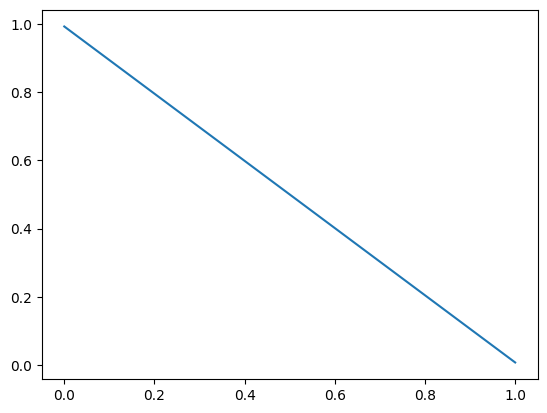

d)
[[ 4.37092209 -0.14156311]
 [-0.07460137  0.34559317]
 [-1.45697403  0.0471877 ]
 [-2.83934669 -0.25121776]]
0.047187703778815454
e)
[7.32379705 0.05120295]

[0.99305723 0.00694277]

[0.36951481 4.41929015]


In [54]:
#a)
mean = M.mean(axis=0)
print(np.linalg.norm(mean))
#b)
print("b)")
M_pca = M - mean
k = 2
pcaM = PCA(n_components=k)
pcaM.fit(M_pca)
print(abs(pcaM.components_[0,0]))
#c)
print("c)")
print(pcaM.explained_variance_ratio_)
plt.plot(pcaM.explained_variance_ratio_)
plt.show()
#d)
print("d)")
M_proj = pcaM.transform(M_pca)
print(M_proj)
print(abs(M_proj[2,1]))
#e)
print("e)")
u, s, vh = np.linalg.svd(M_pca, full_matrices=False)
n = 4
explained_variance = (s ** 2) / (n)
print(explained_variance)
ratio = explained_variance/(sum(explained_variance))
print("")
print(ratio)
whitening_factor = (1/np.sqrt(explained_variance)) + 1e-10
print("")
print(whitening_factor)

**Question 2 (2 marks).** Suppose you have a training data set containing 200000 greyscale images of Hanzi (Chinese characters), each 50x50 pixels large, as well as image labels classifying each character as one of the 3000 most frequent Hanzi.  You decide to pre-process the data using linear discriminant analysis for dimensionality reduction. // __*Vraag 2 (2 punte).*__ *Veronderstel u het 'n afrigdatastel wat 200000 gryskleurige beelde ban Hanzi (Sjinese karakters) bevat, elk 50x50 beeldelemente groot, asook beeldetikette wat elke karakter klassifiseer as een van die 3000 algemeenste Hanzi. U besluit om die data te voorverwerk met lineêre diskriminant analise vir dimensionaliteitsvermindering.*

(a) What is the maximum number of ("non-empty") dimensions your transformed data may have when you have completed this pre-processing? [1] // *Wat is die maksimum aantal ("nie-leë") dimensies wat u getransformeerde data mag hê wanneer u hierdie voorverwerking voltooi het? [1]*

(b) Your initial steps reveal that the rank of the within-class scatter is 2046, and the rank of the between-class scatter is 1812.  What is now the maximum number of ("non-empty") dimensions your transformed data may have when you have completed this pre-processing? [1] // *U aanvanklike stappe wys dat die rang van die binne-klas verspreiding 2046 is, en dat die rang van die tussen-klas verspreiding 1812 is.  Wat is nou die maksimum aantal ("nie-leë") dimensies wat u getransformeerde data mag hê wanneer u hierdie voorverwerking voltooi het? [1]*

In [62]:
#a)
D = 50 * 50
C = 3000
print(min(D,C-1))
#b)
print(1812)

2500
1812


**Question 3 (2 marks).** Consider applying linear discriminant analysis to the UCI ML hand-written digits data set, which is loaded below.  The last line of code in the cell below prints more information on the data set.

(a) Give the rank of the within-class scatter matrix. [1]

(b) Give the length of the first observation projected onto the linear discriminant axes. (Retain all linear discriminant dimensions with non-zero variation.) [1]

__*Vraag 3 (2 punte)*__ *Beskou die toepassing van lineêre diskriminant analise op die (volle) UCI ML handgeskrewe syfers datastel, wat hieronder gelaai word. Die laaste lyn kode in die sel hieronder druk verdere inligting oor die datastel uit.*

*(a) Gee die rang van die binne-klas verspreidingsmatriks.* [1]

*(b) Gee die lengte van die eerste waarneming geprojekteer op die lineêre diskriminant asse.  (Behou alle lineêre diskriminant dimensies met nie-nul variasie.)* [1]

In [138]:
from sklearn.datasets import load_digits
digits = load_digits()
X = digits.data # observations
y = digits.target # labels
print(digits.DESCR)

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

In [140]:
N, k = X.shape
mean = X.mean(axis=0)
sW = (X - mean)@(X - mean).T
print(np.linalg.matrix_rank(sW))

61


In [180]:
clf = LDA(n_components=9)
fit = clf.fit(X, y)
X_projected = clf.transform(X)
# Retain linear discriminant dimensions with non-zero variation
explained_variance = clf.explained_variance_ratio_
non_zero_mask = explained_variance > 1e-10
X_projected_filtered = X_projected[:, non_zero_mask]

# Calculate the Euclidean length
length_first_obs = np.linalg.norm(X_projected_filtered[:,1])
print(f"(b) Length of the first projected observation: {length_first_obs:.4f}")

(b) Length of the first projected observation: 101.7274


In [148]:
X_projected_filtered

array([[-2.01463220e+00, -5.62348616e+00, -1.86594028e-01, ...,
         1.09348511e-01,  1.83506669e-01,  9.65495420e-01],
       [ 2.20967396e-01,  3.59240033e+00,  2.14901657e+00, ...,
         1.23115093e-01,  3.39210556e+00, -1.20766919e+00],
       [ 2.23485453e+00,  2.70950363e+00,  4.26992781e+00, ...,
        -2.51256615e+00, -1.08370006e+00,  4.22490736e-03],
       ...,
       [-1.04697178e+00,  1.48367733e+00,  3.04170263e+00, ...,
        -1.54913444e+00, -1.99315402e+00,  2.17737830e+00],
       [ 4.07872916e-01, -1.99167301e+00, -3.65835518e-01, ...,
        -9.16595358e-01, -5.26856349e-01, -1.41509141e+00],
       [ 1.74145011e-01,  8.87174627e-01,  1.37776831e+00, ...,
         5.14965352e-02, -3.18833067e+00,  6.91242304e-01]],
      shape=(1797, 9))